# **<span style="color: #000000;background-color: #fff5b1">군집화 사전과제</span>**

### **필수내용**
- 군집화의 개념과 기본 과정
- 거리/유사도 정의와 측정 방법
- 주성분 분석(PCA)의 목적
- 4가지 군집화 알고리즘의 특징과 과정
    - 계층적 군집화
    - k-means
    - DBSCAN
    - GMM
- 군집화 평가 방법 (실루엣 계수, 던 인덱스)

---

### <span style="color: #000000;background-color: #ffdba4">**1. 군집화(Clustering)**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(1) 머신러닝 : 비지도 학습**</span> 
- 머신러닝 : 인공지능의 한 분야로 컴퓨터가 스스로 학습할 수 있도록 도와주는 알고리즘
    - 지도 학습
        - 문제와 정답을 모두 알려주고 학습시키는 방법
        - 정답이 있는 데이터 사용
        - 방식 : 예측값을 이미 만들어둔 정답과 같아지도록 기계를 학습
        - 예시 : 회귀, 분류
    - 비지도 학습
        - 답을 가르쳐주지 않고 학습시키는 방법
        - 정답이 없는 데이터 사용
        - 방식 : 데이터 속의 패턴 또는 각 데이터 간의 유사도를 기계가 학습
        - 예시 : <U>**군집화**</U>, 연관분석

##### <span style="color: #27baff">   **[비지도학습의 특징]** <span>
- 데이터 자체에 내재된 구조를 파악해서 학습
- 정답 레이블 X -> <U>모델의 성능을 명확히 측정할 수 없다!</U>
- 표현 학습 (피처 학습)을 통해 데이터셋의 고유 패턴 식별<BR>

<U>**목표 자체가 명확하지 않고, 데이터에서 새로운 특성을 찾는 등의 목적을 수행하기에 적합**</U>

##### <span style="color: #27baff">   **[비지도학습이 적합한 케이스]** <span>
1. 패턴이 아직 알려지지 않은 경우
2. 패턴이 계속해서 변하는 경우
3. 열린 문제를 해결하고 지식을 일반화해야 하는 경우

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(2) 군집화란?**</span> 
<U>**데이터를 비슷한 특성을 가진 그룹(군집)으로 나누는 비지도 학습 기법**</U>
- 군집(cluster) : 유사한 데이터들의 집합. 서로 다른 군집에 속한 개체들은 비슷하지 않아야 한다.

##### <span style="color: #27baff">   **[비지도학습 : 군집화]** <span>
- 군집화는 종속 변수를 설정하지 않고, 데이터 내부의 패턴을 인식해 유사성을 가진 그룹으로 나눈다. 
    - 사전에 정해진 목표 없이 데이터셋에 존재하는 고유한 패턴을 발견하고 추출 

=> 군집화 : **비지도 학습**으로 분류

##### <span style="color: #27baff">   **[군집화의 목표]** <span>
- 응집도(cohension) 최대화
    - 같은 군집에 속하는 데이터끼리는 최대한 비슷하도록 한다.
- 분리도(separation) 최대화
    - 서로 다른 군집은 최대한 분리되도록 한다.  

=> *데이터 간 유사성을 최대한 잘 유지하면서 서로 다른 그룹은 구분될 수 있도록 하는 것!*


#### <span style="color: #000000;background-color: #ffc2e5">   **1-(3) 군집화 과정**</span> 

##### <span style="color: #27baff">   **[군집화의 기본 과정]** <span>
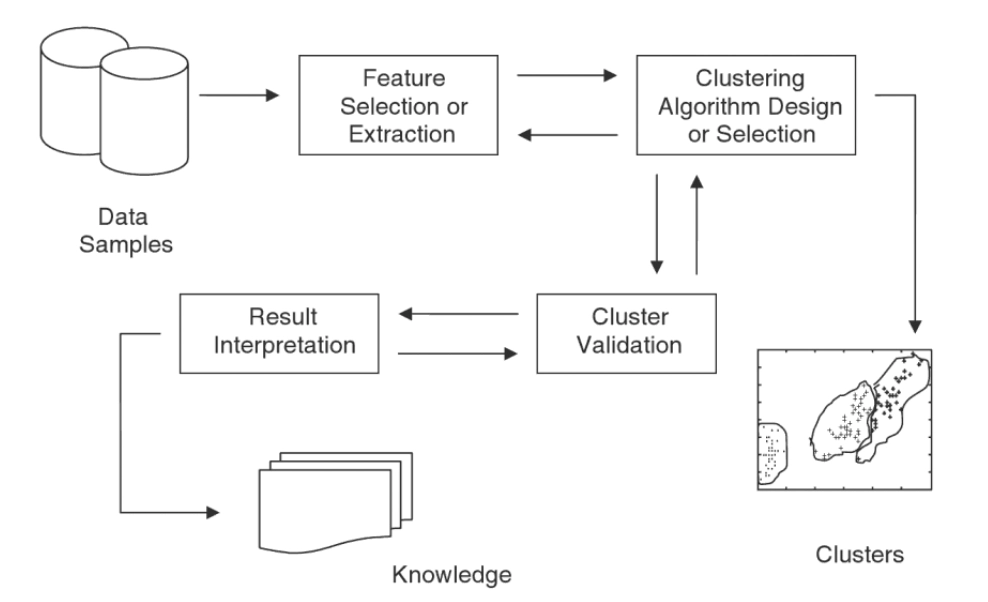  

① **피처 선택 또는 추출** 
- 군집화에 사용할 데이터의 피처(특징) 선택  

② **군집화 알고리즘 선택** 
- 데이터의 특성과 목표에 따라 적합한 군집화 알고리즘 선택  

③ **군집 유효성 검증** 
- 군집화가 얼마나 잘 되었는지 평가  

④ **결과 해석** 
- 각 군집이 지닌 특성 분석 및 해석

### <span style="color: #000000;background-color: #ffdba4">**2. 군집화를 위한 데이터 준비**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(1) 군집화의 주요 고려사항**</span> 
1. **변수 유형 이해**
    - 피처의 종류와 특성을 명확하게 이해해야 한다.
    - 변수의 종류와 개수에 따라 알고리즘이 달라진다.
2. **거리/유사도 정의와 측정**
    - 군집화는 데이터 간의 거리 또는 유사도를 기반으로 그룹 형성
    - 거리 측정 방법에 대한 정의 중요
3. **차원 축소**
    - 변수 증가 -> 모델이 복잡해지고 효율성과 성능이 떨어질 수 있다.
    - 차원 축소를 통해 유사한 변수를 통합 or 필요 없는 변수 제거

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(2) 변수 유형 이해**</span> 
##### <span style="color: #27baff">   **[변수 유형별 군집화 고려사항]** <span>
1. **연속형 변수(Continuous Variables)**
    - 특징 : 수치로 측정 가능
    - 거리 측정 : 유클리디안 거리, 맨하탄 거리 등
    - 적합한 알고리즘 : K-means, 께층적 군집화 등
    - 주의사항 : 스케일링 필수 (단위가 다르면 큰 값의 변수가 지배적 영향)

2. **명목형 변수(Categorical Variables)**
    - 특징 : 범주로 구분
    - 거리 측정 : 해밍 거리(Haming distance), 자카드 거리 등
    - 적합한 알고리즘 : K-modes, 계층적 군집화(특별한 거리 함수 사용)
    - 처리 방법 : 원-핫 인코딩 or 더미 변수 변환

3. **혼합형 변수(Mixed Variables)**
    - 특징 : 연속형 + 명목형
    - 적합한 알고리즘 : K-prototypes, Gower distance 기반 계층적 군집화
    - 처리 방법 : 각 변수 유형에 맞는 거리 함수 조합

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(3) 거리/유사도 정의와 측정**</span> 

##### <span style="color: #27baff">   **[데이터의 거리 측정 방법]** <span>
> 거리가 가까울수록 유사하고 멀수록 다르다고 판단

1. **유클리디안 거리(Euclidean Distance)**  
$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}$  
    - 가장 일반적
    - 직선 거리 의미
    - K-means에서 기본적으로 사용

2. **맨하탄 거리(Mabhattan Distance)**  
$d(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^n |x_i - y_i|$  
    - 각 차원의 차이의 절댓값의 합
    - 이상치에 덜 민감

3. **코사인 유사도(Cosine Similarity)**  
$\text{similarity} = \frac{\mathbf{x} \cdot \mathbf{y}}{||\mathbf{x}|| \times ||\mathbf{y}||}$  
    - 벡터 간 각도 측정
    - 텍스트 데이터 or 고차원 데이터에 효과적

##### <span style="color: #27baff">   **[6가지 연결 방법]** <span>
1. **Single linkage(단일 연결법/최단 연결법)** 
> <U>군집 A와 B 사이의 가장 가까운 두 점 간 거리</U>로 군집 간 거리 정의
- 고립된 군집을 찾는데 중점
- 이상치에 취약  
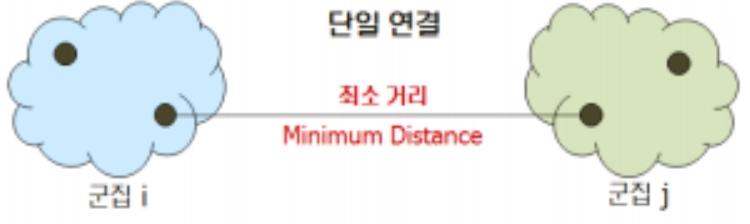

2. **Complete linkage(완전 연결법/최장 연결법)**  
> <U>군집 A와 B 사이의 가장 먼 두 점 간 거리</U>로 군집 간 거리 정의
- 최댓값의 거리로 측정하여 가장 유사성이 큰 군집으로 병합해 나가는 방법
- 군집들의 내부 응집성에 중점
- 이상치에 민감  
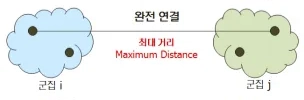

3. **Average linkage(평균 연결법)**  
> <U>군집 A와 B의 모든 점 쌍 사이 거리의 평균</U>
- 모든 항목에 대한 거리 평균을 구한다.
- 이상치에 덜 민감
- 단점 : 계산량이 불필요하게 많아질 수 있다.  
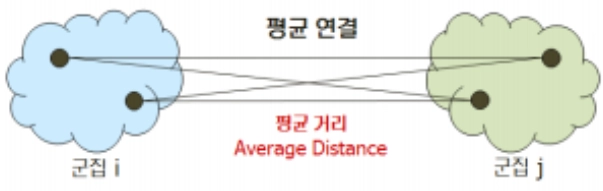

4. **Centroid Method(중심 연결법)**  
> 각 군집의 <U>중심점 간의 거리</U>
- 두 군집의 중심 간의 거리 측정
- 두 군집이 결합될 때 새로운 군집의 평균은 가중평균을 통해서 구한다.
- 군집들의 중심을 계산해야 하기 때문에 시간이 오래 걸린다.
- 덴드로그램에서 거리 축이 위에서 아래로 줄어드는 inversion이 발생할 수 있다.  
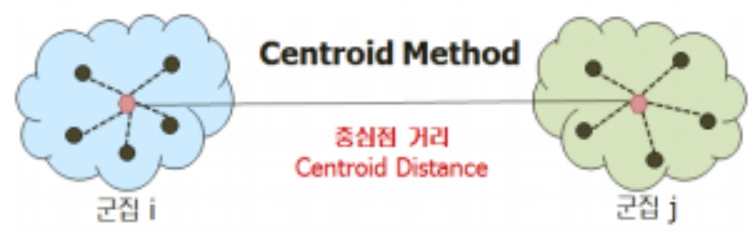

5. **Median(중앙 연결법)**  
> 두 군집의 <U>중앙값 사이의 거리</U>
- 합쳐지는 두 군집의 중심점 사이의 산술적 중간 지점을 새로운 대표값으로 설정하여 거리 측정
- 데이터의 중앙값에 기반해 군집 간 거리 정의 -> 극단값에 영향을 덜 받는다.
- 단점 : 기하학적 구조를 파악하기는 어렵다.

6. **Ward's Procedure(Ward 연결법)**  
> 군집내 <U>제곱합이 증가하지 않도록 병합</U>
- 군집의 병합 후 군집 내 SSE(오차제곱합)의 증가분이 최소인 것을 선택
- 보통 병합된 군집의 SSE는 병합 이전 각 군집의 SSE의 합보다 커지게 되는데 그 증가량이 가장 작아지는 방향으로 군집을 형성해 나가는 방법  
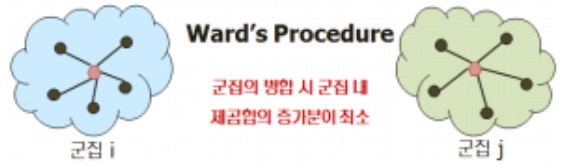

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(4) 차원 축소**</span> 

##### <span style="color: #27baff">   **[차원의 저주]** <span>
<U>**피처 공간이 너무 커서 알고리즘이 데이터를 효과적/효율적으로 훈련할 수 없는 현상**</U>
- 군집화 알고리즘의 많은 부분을 차지하는 거리 기반 알고리즘의 경우, 데이터의 차원이 높아질수록(피처가 많아질수록) 차원의 저주 발생
-> 차원 축소가 필요하다!

##### <span style="color: #27baff">   **[차원 축소]** <span>
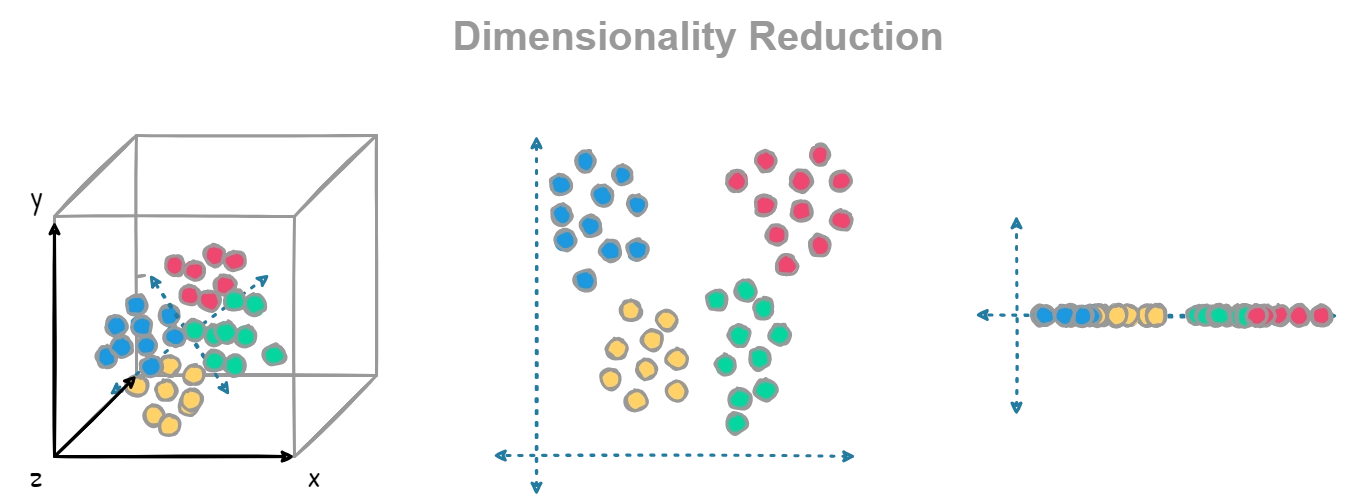  
- 차원 축소에서의차원 : 변수의 개수
    -> 즉, 차원 축소 = 변수의 개수 축소
- 차원 축소의 목표
    - 변수를 제거하여 차원을 낮춰, 고차원 데이터를 저차원 공간에 투영하면서도 핵심 정보는 가능한 지켜내도록 하는 것 -> 노이즈를 줄여 패턴 학습에 유리
- 차원 축소의 유형
    - 선형 투영 
        - 고차원 공간에서 저차원 공간으로 선형적으로 데이터 투영
        - ex) 주성분 분석(PCA), 특잇값 분해(SVD), 랜덤 투영 등
    - 매니폴드 학습(비선형 차원 축소)
        - 유클리드 거리가 아닌 데이터 포인티들 사이의 곡선 거리를 고려하며 학습
        - ex) r-SNE, UMAP, Isomap 등

##### <span style="color: #27baff">   **[PCA(Principal Component Analysis)]** <span>
핵심 목적 : <U>**다차원 데이터에서 가장 정보량이 큰 방향을 찾고, 그 방향을 기준으로 데이터를 투영하여 차원을 줄이는 것**</U>
- PCA(주성분 분석) : 고차원 데이터를 저차원으로 축소하는 차원축소 기법
- 데이터의 분산을 최대한 보존하면서 차원 축소 -> 시각화 & 분석 용이
- 상관관계가 높은 피처들을 결합해 선형적인 상관관계가 없는, 더 적은 수의 피처로 데이터를 표현하길 지향한다.
- 원본의 고차원 데이터에서 최대 분산 방향을 찾아 상관관계를 감소시키고, 저차원 공간에 이들을 투영
    - 새로 파생된 성분 = 주성분

##### <span style="color: #27baff">   **[PCA 사용하기]** <span>
- **주요 파라미터**
    - n_components(주성분 개수)
        - 정수 : 정확히 그 개수만큼 주성분 선택
        - 실수 : 그 비율의 분산을 설명하는 개수 자동 계산
        - None : 모든 주성분 사용(차원 축소 X)
    - whiten(데이터 정규화)
        - True : 각 주성분을 단위분산으로 정규화
        - False(기본값) : 정규화 미적용
    - random_state(랜덤 시드)
        - 재현 가능한 결과를 위해 고정값 설정 권장
<BR>

- **주요 메서드**
    - fit(X) : PCA 모델 학습 (주성분 계산)
    - transform(X) : 데이터를 주성분 공간으로 변환
    - fit_transform(X) : 학습과 변환을 한번에 수행
    - inverse_transform(X) : 원본 공간으로 역변환 (근사값)
<BR>

- **주요 속성들**
    - explained_variance_ratio_
        -각 주성분이 설명하는 분산 비율
    - explained_variance_
        - 각 주성분의 실제 분산값
    - components_
        - 주성분 벡터(원본 특성들의 가중합)
        - 어떤 원본 특성이 각 주성분에 얼마나 기여하는지 표시
    - n_components_
        - 실제 선택된 주성분 개수 (분산 비율로 설정시 유용)

1. 분산 비율 기준으로 자동 선택
> ```python
> pca = PCA(n_components=0.95)  # 95% 분산 설명
> pca.fit(data)
> print(f"필요한 주성분: {pca.n_components_}개")
> ```
2. 고정 개수 선택
> ```python
> pca = PCA(n_components=3)     # 3개 고정
> transformed_data = pca.fit_transform(data)
> print(f"설명 분산: {sum(pca.explained_variance_ratio_):.3f}")
> ```

- 주의사항
    - 표준화 필수 : PCA 전 반드시 데이터 표준화 수행
    - 결측값 처리 : 결측값이 있으면 사용 불가
    - 해석의 어려움 : 주성분은 원본 특성들의 조합이라 직관적 해석이 어렵다.
    - 정보 손실 : 차원축소 과정에서 일부 정보가 손실된다.




### <span style="color: #000000;background-color: #ffdba4">**3. 군집화 알고리즘**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(1) 계층적 군집화(Hierarchical Clustering)**</span>
<U>**데이터 간의 유사성을 기반으로 트리 구조(dendrogram)을 형성하며, 상향식 또는 하향식 방식으로 군집을 형성해 나가는 방법**</U>

##### <span style="color: #27baff">   **[계층적 군집화의 특징]** <span>
- 계층적 군집화 알고리즘은 데이터셋의 관측치를 사용해 **덴드로그램**을 만든다.  
    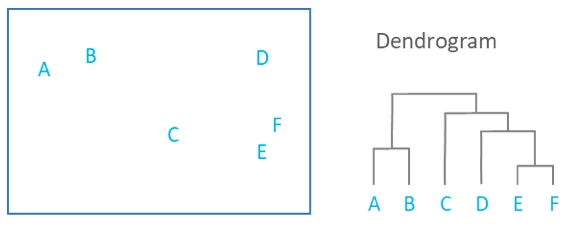  
    - Dendrogram
        - 가까운 두 개체 또는 군집을 점차적으로 병합해가는 과정을 시각적으로 표현한 트리 구조
        - 해석 : 수직축(높이) = 두 군집이 병합될 때의 군집 간 거리(유사성)
- 군집의 개수를 사전에 설정하지 않고, 클러스터링이 종료된 후에 원하는 군집의 개수 선택
- 트리구조 구성 유형
    - 상향식 : 응집형 계층적 군집화
    - 하향식 : 분리형 계층적 군집화

##### <span style="color: #27baff">   **[응집형/분리형 계층적 군집화]** <span>
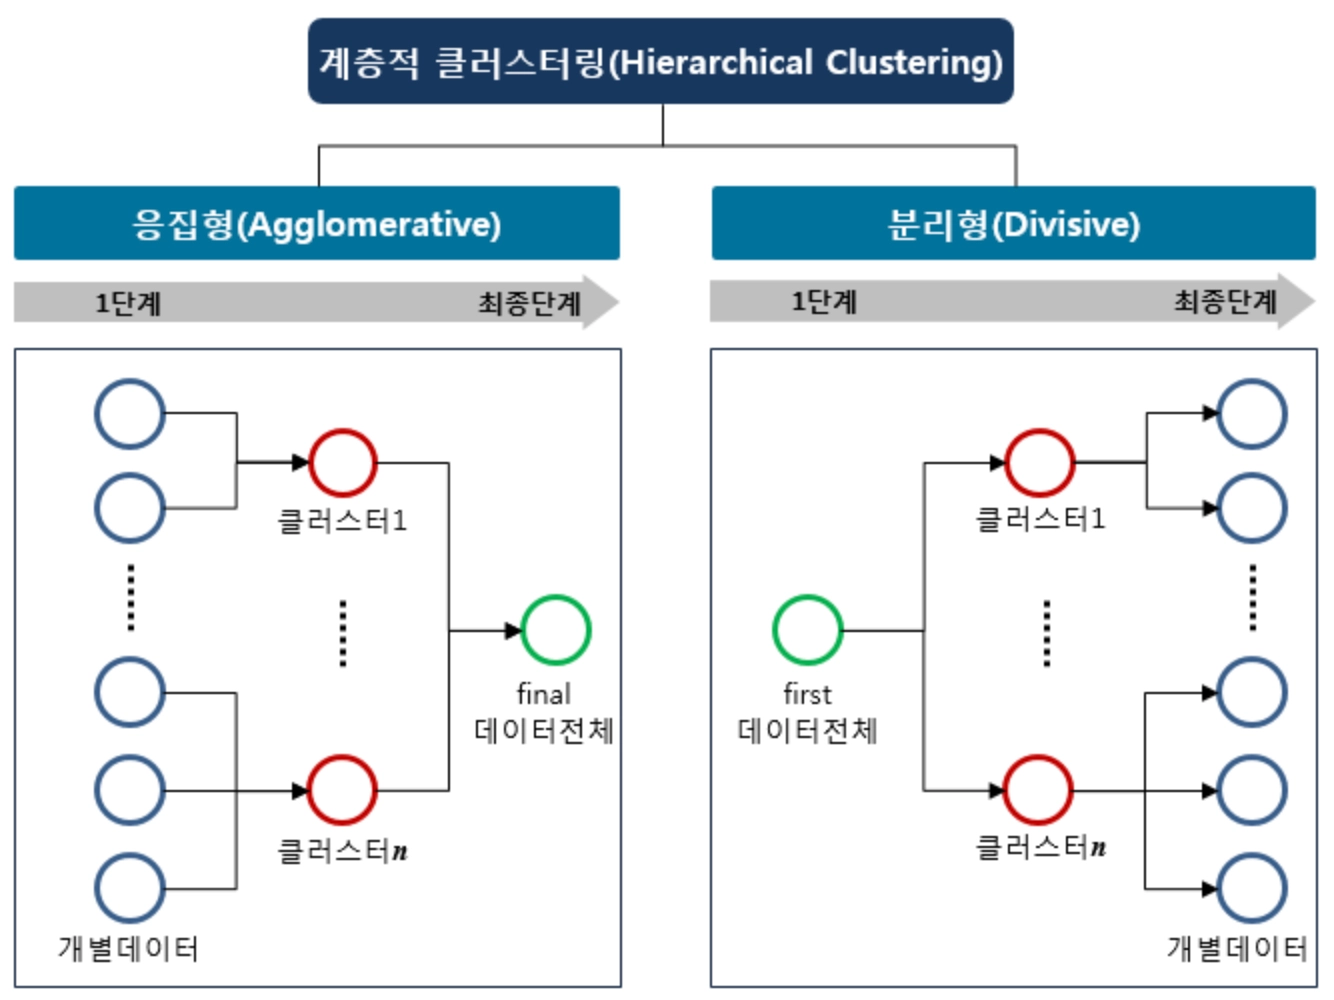
- 응집형 클러스터링
    - 각 샘플이 독립적인 클러스터
    - 이후 하나의 클러스터만 남을 때까지 가장 가까운 클러스터 병합
- 분할형 클러스터링
    - 전체 샘플을 포함하는 하나의 클러스터에서 시작
    - 유사성이 낮은 데이터들을 더 작은 클러스터로 나눈다.
- 특징
    - 데이터를 proximity matrix(거리 행렬 또는 유사도 행렬)에 기반한 계층적 구조로 조직화
    - 결과 : 일반적으로 이진 트리 or dendrogram으로 표현

##### <span style="color: #27baff">   **[응집형 계층적 군집화]** <span>
- 모든 데이터 포인트를 각각 하나의 클러스터로 간주하고 시작 -> 점차적으로 가까운 클러스터들을 병합해 나가는 방식  
- **가장 가까운 클러스터**를 어떻게 정의하느냐에 따라 다양한 알고리즘으로 나뉜다.
- 방식 
    - 단일 연결(가장 가까운 두 샘플의 거리)
    - 완전 연결(가장 먼 두 샘플의 거리)
- 과정  
    ① 거리 행렬 계산   
        - 모든 데이터 포인트 간의 거리를 계산하여 거리 행렬 생성  
    ② 단일 클러스터 시작  
        - 각 데이터 포인트를 개별적인 클러스터로 초기화  
    ③ 가장 가까운 클러스터 병합    
        - 정의된 기준(가장 멀리 있는 샘플 간의 거리)에 따라, 가장 가까운 두 클러스터를 병합하여 새로운 클러스터 생성  
    ④ 거리 행렬 업데이트  
        - 새로 생성된 클러스터와 나머지 클러스터들 간의 거리를 다시 계산 -> 거리 행렬 업데이트  
    ⑤ 반복  
        - 모든 데이터 포인트가 하나의 클러스터에 속할 때까지 3,4번 과정 반복  

##### <span style="color: #27baff">   **[계층적 군집화 시각화]** <span>
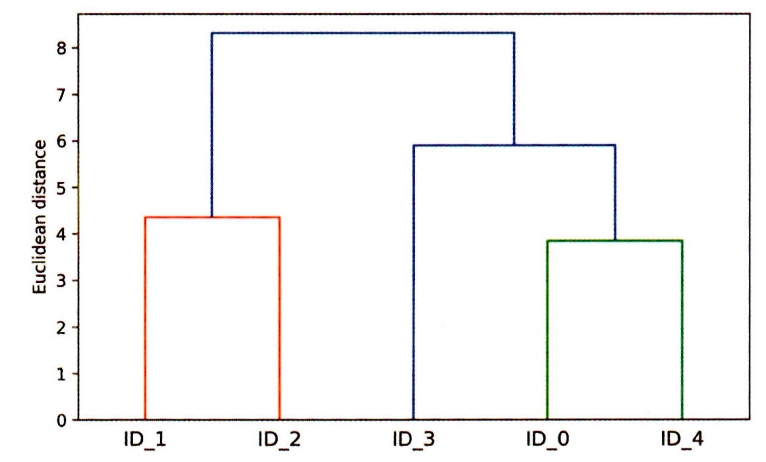
- 덴드로그램을 통해 계층적 군집화가 수행되는 동안 만들어지는 클러스터들을 요약해서 확인할 수 있다.

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(2) k-means**</span> 
##### <span style="color: #27baff">   **[k-means]** <span>
<U>**데이터를 정해진 개수(k)의 그룹으로 나누되, 각 그룹의 중심점과의 거리가 가장 가까운 데이터끼리 묶는 군집화 알고리즘**</U>  

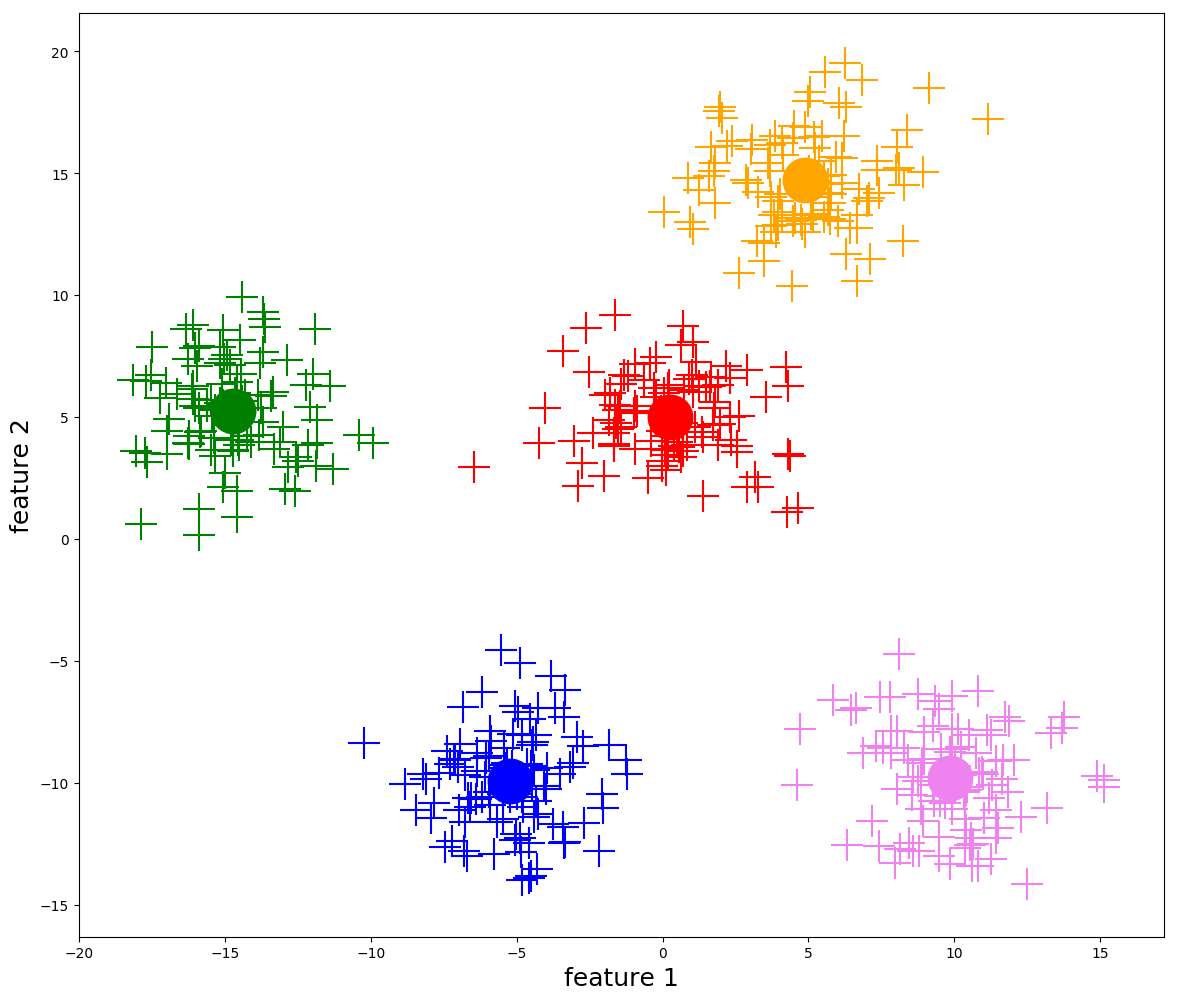  

- 가장 일반적으로 사용되는 알고리즘
- 프로토타입 기반 군집화에 속한다.

##### <span style="color: #27baff">   **[k-means의 주요 단계]** <span>
1. 데이터 표본들 중에서 랜덤하게 k개의 중심점을 초기 클러스터 중심으로 선택  
2. 각 표본들을 가장 가까운 중심점 $\mu^{(j)}, j \in \{ 1, …, k \}$에 할당  
    - 유클리디안 거리 지표 사용-> 특성의 스케일 확인 필요!  

3. 각 클러스터에 할당된 표본들의 데이터 평균을 계산하여 중심점을 이동  
4. 클러스터 할당이 변하지 않거나 사용자가 지정한 허용 오차 또는 최대 반복 횟수(max_iter)에 도달할 때까지 2,3번 반복

##### <span style="color: #27baff">   **[k-means의 장단점]** <span>
- 장점
    - 직관적이고 구현이 쉽다.
    - 대용량 데이터에도 적용 가능
- 단점
    - 초기 centroid 값에 민감
        - 초기 중심점을 랜덤하게 할당하는데, 이에 따라 최종 군집화의 품질이 달라지거나 알고리즘 성능이 하락되는 문제가 있다.
    - 군집 수(k) 결정이 어렵다.
        - 사용자가 직접 지정해야 하며, 이 k값이 결과의 질에 큰 영향을 미친다.
            -> 엘보우 방법, 실루엣 계수를 통해 적절한 k값 탐색
    - 아웃라이어에 민감
        - 평균 중심으로 군집 구성 -> 아웃라이어 하나가 중심 왜곡 가능
    - 기하학적인 모양의 군집은 파악하기 어렵다.

##### <span style="color: #27baff">   **[k-means++ 알고리즘]** <span>
<U>**k-means에서 초기 중심점들을 서로 멀리 떨어진 곳에 위치시켜 더 일관되고 좋은 결과를 도출하는 개선된 초기화 방법**</U>

- 초기화 과정
    1. 선택한 k개의 중심점을 저장할 빈 집합 M을 초기화
    2. 입력 샘플에서 첫번째 중심점 $\mathbf{\mu}^{(i)}$ 을 랜덤하게 선택하고 M에 할당
    3. M에 없는 각 샘플 $\mathbf{x}^{(i)}$ 에 대해 M에 있는 중심점까지의 최소 제곱 거리 $d(\mathbf{x}^{(i)}, \mathbf{M})^2$ 을 찾는다.
    4. 가중치가 적용된 확률분포를 사용해 다음 중심점 $\mathbf{\mu}^{(p)}$ 을 랜덤하게 선택
    5. k개의 중심점을 선택할 때까지 3,4번 반복
    6. 기본 k-means 알고리즘 수행

##### <span style="color: #27baff">   **[엘보우 방법(elbow method)]** <span>
<U>**클래스 내 SSE를 바탕으로 그래프를 활용해 최적 클러스터 개수 k를 추정하는 방법**</U>

- k값을 바꾸어가며 k-means 클러스터링을 진행하고, 왜곡이 빠르게 감소하는 지점의 k값을 찾아 이를 최적 클러스터의 개수로 추정 
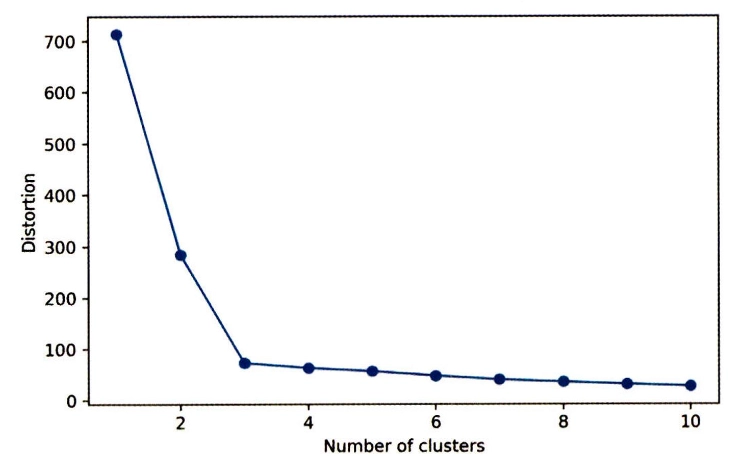  
- 해석
    - 그래프에서 기울기가 급변하는 지점이 최적의 k값
    - 이 그래프에서는 k=3
- 엘보우 방법의 장점
    - 직관적 : 시각적으로 최적의 k값을 쉽게 파악 가능
    - 구현이 간단 : 단순한 반복문&그래프만으로 구현 가능
- 엘보우 방법의 단점
    - 주관적 판단 : elbow 포인트를 결정할 때 주관이 개입
    - 모호한 경우 : 데이터에 따라 엘보우 지점이 명확하지 않을 수 있다.


#### <span style="color: #000000;background-color: #ffc2e5">   **3-(3) DBSCAN**</span>
##### <span style="color: #27baff">   **[DBSCAN]** <span>
<U>**밀도가 높은 지역의 데이터를 하나의 군집으로 묶고, 밀도 기준을 만족하지 못하는 점은 군집에 포함시키지 않는 군집화 알고리즘**</U>
- 밀도에 따라 군집화 진행
- 밀집도 : 특정 거리 내에 존재해야 하는 데이터 포인트의 최소 개수 
- 특징
    - 명시적으로 이상치를 지정하여 클러스터링에서 제외
    - 다른 알고리즘 대비 이상치에 대해 자유롭다.
    - 어떤 데이터가 여러 군집의 특정 거리 내에 있으면 가장 밀도가 높은 군집과 그룹화된다.

##### <span style="color: #27baff">   **[DBSCAN알고리즘의 주요 단계]** <span> 
1. **샘플 분류**
    - 핵심 샘플(Core Point)
        - 특정 반경 ε 안에 있는 이웃 샘플이 지정된 개수(MinPts) 이상인 경우
    - 경계 샘플(Border Point)
        - ε 이내에 MinPts보다 이웃이 적지만
        - 다른 핵심 샘플의 반경 ε 안에 있는 경우
    - 잡음 샘플(Noise Point)
        - 위 두 조건에 해당하지 않는 모든 샘플
<BR>
2. **클러스터 생성**
    - 개별 핵심 또는 ε 이내에 있는 핵심 샘플을 연결한 그룹을 클러스터로 생성
<BR>
3. **경계 샘플 할당**
    - 경계 샘플을 해당 핵심 샘플의 클러스터에 할당

- DBSCAN에서 설정해야 하는 하이퍼파라미터
    - eps : 두 포인트가 이웃이 되기 위한 포인트 사이의 최대 거리
    - min_samples : 한 포인트가 군집이 되기 위한 eps 거리 내 최소 포인트 개수

##### <span style="color: #27baff">   **[DBSCAN의 장단점]** <span> 
- 장점
    - 밀도에 따라 클러스터를 할당하므로 임의의 기하학적 분포를 갖는 데이터 처리 가능
    - 이상치에 민감 X : Noise를 통해 아웃라이어 검출 가능
    - 모든 샘플을 클러스터에 할당하지 않는다.
- 단점
    - epsilon과 min_samples 설정에 많은 영향을 받는다.
    - epsilon 조절이 어렵고, 적절한 조절을 위해서는 데이터셋에 대한 도메인 지식 필요
    - 연산량이 많아 속도가 느리다.
    - 다른 밀도 분포를 가진 데이터의 군집 분석을 잘 하지 못한다.
    - '차원의 저주'의 영향을 받는다.

##### <span style="color: #27baff">   **[HDDBSCAN]** <span> 
<U>**DBSCAN을 계층적 군집화처럼 변환한 버전**</U>  

- 작동 방식
    1. 밀도 기반으로 1차 군집화
    2. 거리 기준으로 밀도 기반 군집들을 반복적으로 연결
- 주요 파라미터
    - min_cluster_size : 클러스터 인정을 위한 최소 샘플 수
    - min_samples : DBSCAN과 동일
- 장점
    - 여러 밀도 기준으로 반복 수행
    - DBSCAN으 ㅣ단일 밀도 기준 한계 보완

#### <span style="color: #000000;background-color: #ffc2e5">   **3-(4) GMM(Gaussian Mixture Model)**</span> 

##### <span style="color: #27baff">   **[Gaussian Mixture Model(GMM)]**<span> 
<U>**데이터가 여러 다른 모양의 가우시안 분포(정규분포)로 구성되었다고 가정하고, 각 분포를 클러스터로 인식하는 군집화 방법**</U>

- 기본 아이디어
    - 단일 분포로 표현하기 어려운 복잡한 형태의 확률분포를 여러 개의 가우시안 분포를 합쳐서 표현하자는 것
- 특징
    - 모델 기반 군집화 (데이터를 생성하는 통계적 모델을 가정하고 데이터가 해당 모델로부터 생성되었다는 전제 하에 군집화 수행)
    - 각 군집을 확률 분포로 간주
    - 전체 데이터 분포를 여러 확률분포의 혼합으로 모델링
    - 데이터의 생성 메커니즘까지 모델링 가능

##### <span style="color: #27baff">   **[GMM의 가정]** <span>
- 기본 가정
    - 관측된 데이터 : 특정 가우시안 확률분포에 의해 생성되었다.
    - 전체 데이터셋 : 여러 개의 다변량 가우시안 분포가 섞여있다.
    - 개별 데이터 : 우도에 따라 k개의 가우시안 분포 중 하나에 속한다.

##### <span style="color: #27baff">   **[GMM의 진행 과정]** <span> 
1. 주어진 전체 데이터셋의 분포 확인  

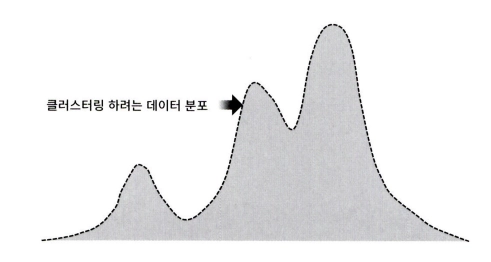    

2. 전체 데이터셋은 서로 다른 정규 분포 형태의 확률분포 곡선으로 구성되어 있다고 가정  

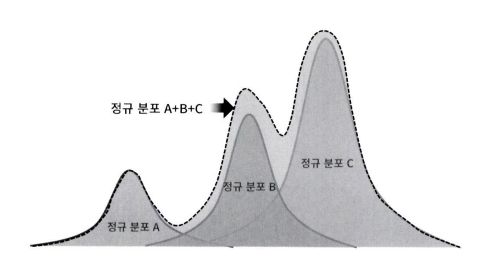  
  
3. 전체 데이터셋을 구성하는 여러 개의 정규분포 곡선을 추출하고, 개별 데이터가 이 중 어떤 정규분포에 속하는지 결정(각각의 분포=하나의 군집)  

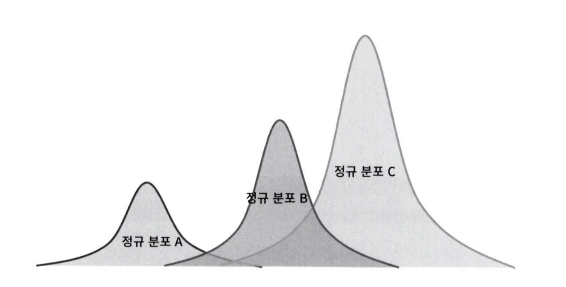

##### <span style="color: #27baff">   **[모델의 파라미터 추정]** <span> 
- 기댓값-최대화(EM) 알고리즘을 사용하여 모델 파라미터 추정
- 추정 가능한 요소 : 각 군집의 중심, 모양, 크기, 방향
- 파라미터 구성
    - $\begin{array}{l} \text{parameter } \theta = (u, \Sigma, \pi) \\ \text{hyper parameter } K(\text{분포 개수}) \end{array}$
- EM 알고리즘 단계
    1. Initialization : 필요한 파라미터에 대해 초기값 설정
    2. E(Expectation) step : 현제 $\theta$ 를 통해 x가 특정 분포(군집)에 속할 사후확률 계산
    3.  M(Maximization) step : 계산된 사후확률을 통해 $u, \Sigma, \pi$ 다시 추정
    4. 수렴 조건이 만족될 때까지 2,3번 반복

##### <span style="color: #27baff">   **[GMM의 장단점]** <span> 
- 장점
    - k-means보다 유연하게 다양한 데이터 세트에 잘 적용될 수 있다.
    - k-means가 잘 작동하지 않는 타원형 분포나, 중첩된 군집 구조에서도 좋은 성능을 낼 수 있다.
- 단점
    - 군집화를 위한 수행시간이 오래 걸린다.
    - 가정한 분포(가우시안 분포)에 맞지 않은 데이터일 경우 계산 복잡도가 높아지고 성능이 저하될 수 있다.

##### <span style="color: #27baff">   **[K-means vs GMM]** <span> 
|구분|k-means|GMM|
|---|---|---|
|기반|중심 기반|확률분포 기반|
|장점|원형 분포에 효과적,빠른 수행 속도|다양한 데이터셋에 유연하게 적용, 길쭉한 분포도 준수하게 처리|
|단점| 길쭉한 분포에서 최적화 어려움|오래 걸림, 정규분포 가정 필요|

### <span style="color: #000000;background-color: #ffdba4">**4. 군집화 평가 방법**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(1) 외부 평가와 내부 평가**</span> 
##### <span style="color: #27baff">   **[외부 평가(External Evaluation)]** <span> 
- 데이터에 정답 레이블이 존재하는 경우에 사용
- 군집화 결과와 실제 정답을 비교하여 얼마나 유사한지 평가
- 대표적인 지표 : ARI(Adjusted Rand Index)

##### <span style="color: #27baff">   **[내부 평가(Internal Evaluation)]** <span> 
- 데이터에 정답 레이블이 없는 경우에 사용
- 군집 내부 **응집도**와 군집 간 **분리도**를 기반으로 정량적 측정
    -> 데이터 자체의 구조를 기반으로 군집 품질 판단
- 알고리즘 자체의 내부 평가 지표와 범용적으로 사용 가능한 내부 평가 지표 존재
- 알고리즘 별 내부 평가 지표
    - k-means : SSE(Sum of Squared Errors) 최소화
    - GMM : 로그 우도(모델이 주어진 데이터를 얼마나 잘 설명하는지 나타내는 지표) 최대화
- 대표적인 범용적 지표 : 실루엣 계수, 던 지수

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(2) 실루엣 계수**</span> 
<U>**클리스터 내 샘플들이 얼마나 조밀하게 모여있는지를 측정하는 도구**</U>

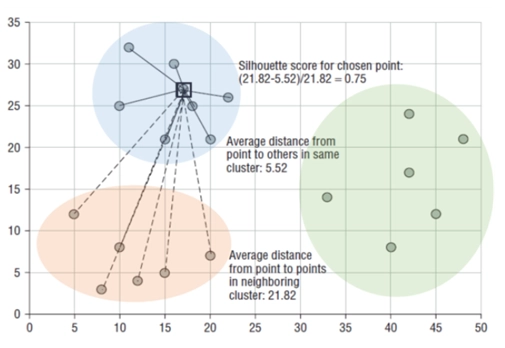

##### <span style="color: #27baff">   **[실루엣 계수 계산]** <span> 
1. 샘플 $x^{i}$ 와 동일한 클러스터 내 모든 다른 포인트 사이의 거리를 평균하여 클러스터 응집력 $a^{i}$ 계산
2. 샘플 $x^{i}$ 와 가장 가까운 클러스터의 모든 샘플 간 평균 거리로 최근접 클러스터의 클러스터 분리도 $b^{i}$를 계산
3. 클러스터 분리도에서 응집도를 뺀 값을 둘 중 큰 값으로 나누어 실루엣 $s^{i}$ 계산

$s^{(i)} = \frac{b^{(i)} - a^{(i)}}{\max \left\{ b^{(i)}, a^{(i)} \right\}}$

##### <span style="color: #27baff">   **[실루엣 계수 해석]** <span> 
- 실루엣 계수는 -1과 1 사이 값을 가진다.
- 분리도가 응집도보다 큰 경우, 이상적인 실루엣 계수인 1에 가까워진다
    - 샘플이 자신의 클러스터에 잘 속해있고, 다른 클러스터와는 멀리 떨어져있음을 의미
    - 군집화가 잘 되었다고 평가(0.7이상이면 보통 군집화가 잘 되었다고 해석)
- 분리도와 응집도가 같을 경우, 실루엣 계수=0
- 분리도가 응집도보다 작은 경우, 실루엣 계수는 -1에 가까워진다.
    - 샘플이 잘못된 클러스터에 할당됨
    - 군집화가 잘 되지 않았다고 평가

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(3) Dunn Index**</span> 
<U>**클러스터 간 최소 거리(분리도)와 클러스터 내 최대 거리(응집도)의 비율을 계산해 클러스터링의 품질을 평가하는 지표**</U>

##### <span style="color: #27baff">   **[Dunn Index 계산]** <span> 
$s^{(i)} = \frac{b^{(i)} - a^{(i)}}{\max \left\{ b^{(i)}, a^{(i)} \right\}}$

- $d(C_i, C_j)$ : 클러스터 $C_i$와 $C_j$ 사이의 거리(분리도)
    - 일반적으로 클러스터 중심 사이의 거리 or 두 클러스터 간 최소 거리
- $\delta(C_k)$ : 클러스터 $C_k$ 내의 최대 거리(응집도)
    - = 해당 클러스터 안에서 가장 멀리 떨어진 두 점 간 거리

##### <span style="color: #27baff">   **[Dunn Index 해석]** <span> 
- 값이 클수록 좋은 군집화 결과
    -> 군집 간 거리가 크고(분리도가 높음), 군집 내부 거리는 작다(응집도가 높음)
- 일반적으로 0 이상의 값을 가지며 무한대까지 가능
- 실루엣 계수와 종합적 평가를 권장

##### <span style="color: #27baff">   **[Dunn Index의 한계]** <span> 
- 군집 수가 많아질수록 계산 비용 증가
- 극단적인 값에 큰 영향을 받는다
- 이상치에 민감